# MRAC-RL:AFrameworkfor On-Line Policy Adaptation Under Parametric Model Uncertainty

Original paper: 
Authors: Anubhav Guha, Anuradha Annaswamy
Massachusetts Institute of Technology, Cambridge, MA 02139
https://arxiv.org/pdf/2011.10562

## Motivation

In the past lectures we discovered Model Reference Adaptive Control (MRAC) as a powerfull framework that can effectively handle modeling uncertainties by adapting control parameters in real time.
MRAC is strong on the adaption, using Lyapunov proven convergence. However it requires first of defining a suitable reference model. For complex systems or multi-objective functions or non-linear or stochastic or constrained systems deriving a reference model is not trivial.
Here is where a powerful tool as Reinforcement Learning (RL) arives.
RL enables policy optimization through data-driven interaction with dynamic environments. Basically we are going to learn a control function that maps states to actions, without explicitly defining it. We can treat the environment as a black box.
RL policies, although powerful, often struggle to generalize beyond the training environment, leading to the well-known "sim-to-real" gap.

MRAC-RL arives as a framework to bring the RL policy from simulation to the real world. Basically we will add an adaption mechanism to the RL policy. 
The idea is to use the RL policy as our reference model: "we treat the reference model as the closed-loop system formed by the simulation model and the RL-derived control policy".
The MRAC task is then to drive the “true” system to track this closed-loop reference model.
The RL component may be viewed as an outer-loop block, while the MRAC component may be viewed as an inner-loop block.

## RL & MRAC Generalities

### Reinforcement Learning

#### The Core Idea

Reinforcement Learning is a framework for sequential decision-making. An **agent** interacts with an **environment** over discrete time steps: at each step $k$, the agent observes the current state $x_k$, selects an action $u_k$, and receives a scalar **reward** $\rho_k$ (or equivalently, incurs a **cost** $c_k = -\rho_k$). The agent's goal is to find a **policy** $\pi : \mathcal{X} \to \mathcal{U}$, i.e. a mapping from states to actions, that minimizes the accumulated cost over time:

$$\min_{\pi} \sum_{k=0}^{T} c(x_k, u_k, k), \qquad u_k = \pi(x_k)$$

Notice that we are not handing the agent a model of the environment. It discovers the consequences of its actions by interacting with the environment — this is what makes RL **data-driven**. The policy $\pi$ is typically parameterized (e.g. as a deep neural network) and updated iteratively through this interaction.

For continuous control tasks, several well-established deep RL algorithms exist. The paper benchmarks against three of them:

- **PPO** (Proximal Policy Optimization): an on-policy algorithm that updates the policy by taking gradient steps while constraining how much the policy changes per update, preventing destabilizing large steps.
- **SAC** (Soft Actor-Critic): an off-policy algorithm that additionally maximizes the entropy of the policy, encouraging exploration and robustness.
- **DDPG** (Deep Deterministic Policy Gradient): an off-policy algorithm designed specifically for continuous action spaces, maintaining a deterministic policy and a learned critic.

For this tutorial the specific algorithm used does not matter — the key observation is that **any** of them produces a policy $\pi$ that maps states to actions, and that policy is what we will plug into the MRAC-RL outer loop.

#### The Formal Problem

The paper poses the control problem as a continuous-time optimal control problem. Given the true dynamical system:

$$\dot{x}(t) = f(x(t), u(t), \phi), \qquad x(0) = x_0, \qquad u(t) \in \mathcal{U}$$

where $\phi$ are **system parameters that may be uncertain**, we want to find the control $u(t)$ that minimizes:

$$\min_{u(t)} \int_0^T c(x(t), u(t), t)\, dt$$

In practice RL treats this as a discrete-time Markov Decision Process (MDP), but for analysis purposes we retain continuous-time notation — the trained policy is applied continuously between discrete update steps.

#### Why RL Policies Fail at Sim-to-Real

Training RL in simulation is practically necessary: it allows a near-infinite number of safe interactions at low cost. However, this introduces a critical vulnerability. When training, the agent implicitly assumes that the environment follows the **reference dynamics**:

$$\dot{x}_r(t) = f_r(x_r(t), u_r(t), \phi_r)$$

where $\phi_r$ are the **nominal** (simulated) parameter values. The trained policy $\pi$ learns to be optimal specifically for this model. When deployed on the **true system** — where $\phi \neq \phi_r$, so $f \neq f_r$ — the policy is applied directly as $u(t) = \pi(x(t))$. Since $\pi$ was never exposed to the true dynamics, the true state trajectory $x(t)$ diverges from the simulated trajectory $x_r(t)$ the policy was optimized for, and performance degrades. This divergence is the **sim-to-real gap**.

To make this concrete: suppose an RL policy was trained to balance an inverted pendulum with mass $m_r = 1$ kg and length $l_r = 1$ m. If the true pendulum has $m = 1.25$ kg and $l = 0.75$ m, the inertia $ml^2$ differs by roughly 30%. The policy's learned force commands are now systematically wrong — they assume the wrong inertia — and steady-state errors or instability can result.

### Model Reference Adaptive Control (Review)

You have seen MRAC in detail in previous lectures. We briefly recall the key ideas here in the language that the paper uses, which differs slightly in notation from Yucelen's framework.

#### The Setup

MRAC addresses a different but related problem: given a plant with **unknown parameters**, find a controller that drives the plant to track a **known reference model**. The reference model captures the desired closed-loop behavior. The paper works with systems in **controllable canonical form**:

$$\dot{x}(t) = Ax(t) + Bu(t)$$

$$A = \begin{bmatrix} 0 & 1 & 0 & \cdots & 0 \\ \vdots & & \ddots & & \vdots \\ a_1 & a_2 & a_3 & \cdots & a_n \end{bmatrix}, \qquad B = \begin{bmatrix} 0 \\ \vdots \\ 0 \\ b \end{bmatrix}$$

The key structural feature is that **all dynamics enter through a single scalar channel** in the last row — the system is fully actuated through one input that multiplies a single non-zero entry $b$ in $B$. The **unknown** parameters are $a_1, \ldots, a_n$ and $b$ (their signs are assumed known). The known reference model has the same form with known parameters $a_{1,r}, \ldots, a_{n,r}$ and $b_r$.

Crucially, the paper rewrites the true system as:

$$\dot{x}(t) = Ax(t) + \lambda B_r u(t)$$

where $\lambda > 0$ is an **unknown scalar** representing the ratio between the true and reference input effectiveness, and $B_r$ is the known reference input matrix. This is the representation from our previous lectures — matched uncertainty with unknown control effectiveness.

#### The Reference Model and Tracking Objective

The reference model is:

$$\dot{x}_r(t) = A_r x_r(t) + B_r u_r(t)$$

The tracking error is $e(t) = x(t) - x_r(t)$, and the MRAC goal is:

$$\lim_{t\to\infty} \|e(t)\| = 0$$

## RL-MRAC Framework

### Linear Example

#### Ideal Control Law and Matching Conditions

If $\lambda, A$ were known, we could design a perfect tracking controller. The **ideal control law** that achieves $e(t) \equiv 0$ is:

$$u^*(t) = K_x^\top x(t) + k_u u_r(t)$$

where $K_x \in \mathbb{R}^n$ and $k_u \in \mathbb{R}$ satisfy the **matching conditions**:

$$A + \lambda B_r K_x^\top = A_r, \qquad \lambda k_u B_r = B_r \implies \lambda k_u = 1$$

The first condition says: the ideal feedback term exactly compensates the difference between the true $A$ and the desired $A_r$.\
The second says: the ideal feedforward gain exactly compensates for the unknown $\lambda$. \
Since both $A$ and $\lambda$ are unknown, so are $K_x^*$ and $k_u^*$ — we cannot implement $u^*$ directly.

#### Constructing a Stable Error System via the $A_H$ Matrix

Here the paper introduces a clever construction that does not appear in the simpler MRAC from previous lectures. The reason it is needed is that the error dynamics with the canonical form system have a specific structure that must be handled carefully to guarantee that $A_H$ (the matrix governing the error dynamics) is Hurwitz.

Recall that $A_r$ has all its dynamics in its last row, represented by the vector $\alpha_r = [a_{1,r}, a_{2,r}, \ldots, a_{n,r}]^\top \in \mathbb{R}^n$.\
Define the vector $h = [0, 0, \ldots, 0, 1]^\top \in \mathbb{R}^n$, so that the last row of $A_r$ can be written as $h \alpha_r^\top$.

Now define a **diagonal matrix** $D \in \mathbb{R}^{n \times n}$ with entries:

$$D_{ii} = \begin{cases} \omega_i > 1 & \text{if } a_{i,r} > 0 \\ \psi_i \leq 0 & \text{if } a_{i,r} < 0 \end{cases}$$

The diagonal entries of $D$ are chosen based on the **sign** of the corresponding reference model parameter $a_{i,r}$ — information that is available since the signs of $A_r$ are known. The construction ensures that the vector $v = \alpha_r - D\alpha_r$ has **strictly negative entries** for every $i$:

- If $a_{i,r} > 0$: then $v_i = a_{i,r} - \omega_i a_{i,r} = (1 - \omega_i)a_{i,r} < 0$ since $\omega_i > 1$.
- If $a_{i,r} < 0$: then $v_i = a_{i,r} - \psi_i a_{i,r} = (1-\psi_i)a_{i,r}$. Since $\psi_i \leq 0$ we have $1 - \psi_i \geq 1 > 0$, and $a_{i,r} < 0$, so $v_i < 0$.

This sign structure is what guarantees that the matrix:

$$A_H := A_r - h(D\alpha_r)^\top$$

is **Hurwitz**. Intuitively, $A_H$ is obtained from $A_r$ by modifying only its last row (through $h$), shifting the eigenvalues strictly into the left half-plane by subtracting a term $h(D\alpha_r)^\top$ that makes all effective "feedback" coefficients in the last row strictly negative. This is a known result for companion-form matrices: a companion matrix is Hurwitz if and only if all coefficients in its last row are strictly negative.

#### The Adaptive Controller and the Augmented Reference Input

Since $K_x^*$ and $k_u^*$ are unknown, we replace them with **adaptive estimates** $\hat{K}_x(t)$ and $\hat{k}_u(t)$. The control law is:

$$\boxed{u(t) = \hat{K}_x^\top(t)\, x(t) + \hat{k}_u(t)\, \xi(t)}$$

where the **augmented reference input** $\xi(t)$ is defined as:

$$\xi(t) := u_r(t) - \frac{1}{b_r}(D\alpha_r)^\top e(t)$$

The $\xi$ term looks unusual at first. To understand it, notice that the naive choice $u = \hat{K}_x^\top x + \hat{k}_u u_r$ would produce error dynamics involving $A_r$ — which is not Hurwitz in general (it is a companion matrix for an open-loop system). The role of the $-\frac{1}{b_r}(D\alpha_r)^\top e$ term is precisely to **replace $A_r$ with $A_H$** in the error dynamics, guaranteeing the Hurwitz property needed for the Lyapunov proof. It is a **stabilizing injection** that the designer adds on top of the reference input, using only known quantities ($b_r$, $D$, $\alpha_r$, $e$).

#### Deriving the Error Dynamics

Define the parameter estimation errors:
$$\tilde{K}_x = \hat{K}_x - K_x^*, \qquad \tilde{k}_u = \hat{k}_u - k_u^*$$

Compute $\dot{e} = \dot{x} - \dot{x}_r$. Substituting the plant and controller:

$$\dot{e} = Ax - A_r x_r - B_r u_r + \lambda B_r\!\left[\hat{K}_x^\top x + \hat{k}_u\!\left(u_r - \frac{1}{b_r}(D\alpha_r)^\top e\right)\right]$$

Add and subtract $\lambda B_r K_x^{*\top} x$ and use the matching condition $A + \lambda B_r K_x^{*\top} = A_r$:

$$\dot{e} = A_r(x - x_r) - \lambda \hat{k}_u h(D\alpha_r)^\top e + \lambda B_r\!\left[\tilde{K}_x^\top x + \tilde{k}_u\,\xi\right]$$

Now use that $A_r = M + h\alpha_r^\top$ (where $M$ contains all rows of $A_r$ except the last, which is zeroed out), so $A_r(x-x_r) = Me + h\alpha_r^\top e$. Also use $\lambda k_u^* = 1$. After careful regrouping (shown in full in Appendix A of the paper):

$$\boxed{\dot{e}(t) = A_H e(t) + \lambda B_r\!\left[\tilde{K}_x^\top(t)\, x(t) + \tilde{k}_u(t)\, \xi(t)\right]}$$

This is structurally identical to the error dynamics from the previous lectures, with $A_H$ playing the role of $A_m$. The key properties are: $A_H$ is Hurwitz by construction, and the parameter error terms multiply $\lambda B_r$ — so the unknown $\lambda$ will need to be handled in the Lyapunov function, exactly as before.

#### Lyapunov Analysis and Update Laws

Consider the Lyapunov function candidate:

$$V(e, \tilde{K}_x, \tilde{k}_u) = e^\top P e + \lambda\, \text{tr}\!\left(\tilde{K}_x^\top \Gamma_x^{-1} \tilde{K}_x\right) + \lambda\, \frac{\tilde{k}_u^2}{\gamma_u}$$

where $P = P^\top \succ 0$ solves $PA_H + A_H^\top P = -Q$ for some $Q = Q^\top \succ 0$, $\Gamma_x = \Gamma_x^\top \succ 0$, and $\gamma_u > 0$.

**Note on the $\lambda$ factor:** Unlike the analysis in the previous lecture (where $\Lambda$ appeared inside the trace as $\tilde{K}^\top \Gamma^{-1} \tilde{K}^\top \Lambda$), here $\lambda$ is a scalar, so $\tilde{K}^\top \Gamma^{-1} \tilde{K} \cdot \lambda = \lambda\, \text{tr}(\tilde{K}_x^\top \Gamma_x^{-1} \tilde{K}_x)$ and $\lambda \frac{\tilde{k}_u^2}{\gamma_u}$ serve the same structural role — they introduce $\lambda$ into the Lyapunov terms to cancel the $\lambda$ that appears in the error dynamics. The scalar case simplifies the algebra considerably compared to the matrix $\Lambda$ case.

**Positive definiteness:** Since $P \succ 0$, $\Gamma_x \succ 0$, $\gamma_u > 0$, and $\lambda > 0$, each term in $V$ is non-negative and zero only when $e = 0$, $\tilde{K}_x = 0$, $\tilde{k}_u = 0$. So $V$ is positive definite. ✓

**Time derivative:** Using $\frac{d}{dt}(e^\top Pe) = 2e^\top P\dot{e}$ and $\frac{d}{dt}\text{tr}(\tilde{K}_x^\top \Gamma_x^{-1}\tilde{K}_x) = 2\,\text{tr}(\tilde{K}_x^\top \Gamma_x^{-1} \dot{\hat{K}}_x)$:

$$\dot{V} = 2e^\top P\dot{e} + 2\lambda\,\text{tr}\!\left(\tilde{K}_x^\top \Gamma_x^{-1} \dot{\hat{K}}_x\right) + \frac{2\lambda \tilde{k}_u \dot{\hat{k}}_u}{\gamma_u}$$

Substituting the error dynamics and expanding $2e^\top P A_H e = e^\top(PA_H + A_H^\top P)e = -e^\top Qe$:

$$\dot{V} = -e^\top Qe + 2\lambda\!\left[e^\top P B_r \tilde{K}_x^\top x + \text{tr}\!\left(\tilde{K}_x^\top \Gamma_x^{-1}\dot{\hat{K}}_x\right)\right] + 2\lambda\!\left[e^\top P B_r \tilde{k}_u \xi + \frac{\tilde{k}_u \dot{\hat{k}}_u}{\gamma_u}\right]$$

Apply the scalar trace identity $e^\top P B_r \tilde{K}_x^\top x = \text{tr}(\tilde{K}_x^\top x e^\top P B_r)$ to the first bracket:

$$\dot{V} = -e^\top Qe + 2\lambda\,\text{tr}\!\left(\tilde{K}_x^\top\!\left[xe^\top PB_r + \Gamma_x^{-1}\dot{\hat{K}}_x\right]\right) + 2\lambda \tilde{k}_u\!\left[\xi e^\top PB_r + \frac{\dot{\hat{k}}_u}{\gamma_u}\right]$$

Setting each bracket to zero — for all possible values of $\tilde{K}_x$ and $\tilde{k}_u$ — gives the **update laws**:

$$\boxed{\dot{\hat{K}}_x(t) = -\Gamma_x\, x(t)\, e^\top(t) P B_r}$$

$$\boxed{\dot{\hat{k}}_u(t) = -\gamma_u\, \xi(t)\, e^\top(t) P B_r}$$

With these choices:

$$\dot{V}(e, \tilde{K}_x, \tilde{k}_u) = -e^\top Q e \leq 0$$

**Remarks on the update laws:**

- $e^\top(t) P B_r$ is a **scalar** (since $B_r \in \mathbb{R}^{n \times 1}$ and $e \in \mathbb{R}^n$, the product $P B_r \in \mathbb{R}^n$, and $e^\top(PB_r) \in \mathbb{R}$). This single scalar drives both update laws simultaneously.
- $\dot{\hat{K}}_x \in \mathbb{R}^n$: the outer product $x(t)\, e^\top(t) P B_r$ is a vector times a scalar. ✓
- $\dot{\hat{k}}_u \in \mathbb{R}$: $\xi(t)\, e^\top(t) PB_r$ is scalar times scalar. ✓
- $\lambda$ does **not** appear in either update law. As in the previous lectures, the $\lambda$ factors in the Lyapunov function and the error dynamics cancel exactly. The controller adapts correctly despite never knowing $\lambda$.

#### Stability Conclusion (Theorem 2)

The argument follows the standard Barbalat chain:

1. $V \geq 0$ and $\dot{V} = -e^\top Qe \leq 0$, so $V(t) \leq V(0) < \infty$ for all $t$. This means $e, \tilde{K}_x, \tilde{k}_u \in \mathcal{L}_\infty$.
2. Since $e \in \mathcal{L}_\infty$ and $x_r \in \mathcal{L}_\infty$ (assumed bounded from the RL policy), then $x = e + x_r \in \mathcal{L}_\infty$.
3. Boundedness of $\hat{K}_x, \hat{k}_u, x, u_r$ implies $u \in \mathcal{L}_\infty$, hence $\dot{x} \in \mathcal{L}_\infty$, hence $\dot{e} \in \mathcal{L}_\infty$.
4. Therefore $\ddot{V} = -2e^\top Q\dot{e}$ is bounded, so $\dot{V}$ is **uniformly continuous**.
5. By **Barbalat's Lemma**: $\dot{V}(t) \to 0$ as $t \to \infty$, which implies $e(t) \to 0$. $\square$

The theorem requires two mild conditions: $\|x_r(t)\| < M_x$ and $\|u_r(t)\| < M_u$ for all $t$. These are conditions on the **RL policy** — namely, that the policy generates bounded trajectories in the reference model. This is a reasonable assumption for any well-trained RL policy on a physically sensible task.


### Hands On Python implementation for Linear Model

#### **Motivating Example: Set-point Randomized Inverted Pendulum (SRIP)**

The papers use the **SRIP task** because it is more challenging than a simple "swing-up". In a swing-up, the goal is an equilibrium where the control effort eventually goes to zero. In SRIP, the goal is to hold a **random angle** (set-point), which requires constant, non-zero torque. This makes the system very sensitive to modeling errors: if your "true" mass is heavier than your "simulated" mass, the RL policy won't provide enough torque to hold the angle.

The linear dynamics are defined as:
$$ml^2\ddot{\theta} = mgl\theta - b\dot{\theta} + u$$
*   **Parameters:** $m$ (mass), $l$ (length), and $b$ (viscous drag) are assumed to be unknown or different from simulation.
*   **MRAC Goal:** We pick adaptive laws for two parameters: $\hat{K}_x$ (state gains) and $\hat{k}_u$ (input gain). 
*   **The Result:** Even if the mass $m$ changes by 25% during the test, the inner loop adapts $\hat{K}_x$ and $\hat{k}_u$ so that the tracking error $e \to 0$.

#### RL Policy

##### Environment definition

Let's take the classical gym [pendulum](https://gymnasium.farama.org/environments/classic_control/pendulum/) environment. ([Repo](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/pendulum.py))

**Action Space**: 
The action is a ndarray with shape (1,) representing the torque applied to free end of the pendulum. `Box(-2.0, 2.0, (1,), float32)`
**Observation Space**: The observation is a ndarray with shape (3,) representing the x-y ($\cos(\theta)$, $\sin(\theta)$) coordinates of the pendulum’s free end and its angular velocity ($\omega$). `Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)`

In [1]:
import gymnasium as gym

gym.register(
    id="LinearSRIPPendulum-v0",
    entry_point="srip_pendulum_env:LinearSRIPPendulumEnv",
    kwargs={"render_mode": "rgb_array"},
    max_episode_steps=200,
)

linear_env = gym.make("LinearSRIPPendulum-v0")

##### Training
It takes from 2-3 hours to train using CPU.\
Parameters taken from the appendix of the paper
* $T=200$: Horizon - Number of steps
* $\gamma=0.99$: Discount factor
* $\alpha=5\times 10^{-4}$: Learning rate for both actor and critic networks
* Total time (training) steps: $8\times 10^{4}$

In [2]:
%%time
from stable_baselines3 import SAC

linear_env.reset(seed=42)
model = SAC("MlpPolicy", linear_env, 
            gamma=0.99, learning_rate=5e-4,
            verbose=1)

model.learn(total_timesteps=8e5, log_interval=50)
model.save("models/sac_linear_pendulum")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -296     |
| time/              |          |
|    episodes        | 50       |
|    fps             | 59       |
|    time_elapsed    | 168      |
|    total_timesteps | 10000    |
| train/             |          |
|    actor_loss      | 67.2     |
|    critic_loss     | 1.17     |
|    ent_coef        | 0.112    |
|    ent_coef_loss   | -0.0644  |
|    learning_rate   | 0.0005   |
|    n_updates       | 9899     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -157     |
| time/              |          |
|    episodes        | 100      |
|    fps             | 59       |
|    time_elapsed    | 338      |
|    total_timesteps | 20000    |
| train/             |

##### Evaluation

In [3]:
import io
import imageio
from IPython.display import Image, display

import numpy as np

def rad2deg(rad):
    return rad*180/np.pi

def angle_normalize(x):
    return ((x + np.pi) % (2 * np.pi)) - np.pi

def evaluate(model, env, seed=42, options=None):
    frames = []
    history = {
        'r': [],
        't': [],
        'theta': [],
        'omega': [],
        'u': [],
        'reward': [],
        'error': []
    }
    
    obs, info = env.reset(seed=seed, options=options)
    step_count = 0
    dt = env.unwrapped.dt
    while step_count <=200:
        frames.append(env.render())  # Capture frame
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        step_count += 1

        r = angle_normalize(env.unwrapped.target_angle)
        theta = angle_normalize(env.unwrapped.state[0])
        history['r'].append(rad2deg(r))
        history['t'].append(step_count * dt)
        history['theta'].append(rad2deg(theta))
        history['omega'].append(env.unwrapped.state[1])
        history['u'].append(env.unwrapped.last_u)
        history['reward'].append(reward)
        history['error'].append(angle_normalize(r - theta))
        
        if terminated or truncated:
            break
    
    gif_io = io.BytesIO()
    imageio.mimsave(gif_io, frames, format="GIF", fps=int(1 / dt), loop=0)
    gif_io.seek(0)
    
    return history, gif_io

This code is to plot the history and compare the signals

In [4]:
import matplotlib.pyplot as plt

def plot_history(history, history_model, adaptation=False):
    fig = plt.figure(figsize=(10, 8)) if adaptation else plt.figure(figsize=(8, 8))
    time = history['t']
    plt.subplot(2,2,1) if adaptation else plt.subplot(3,1,1)
    plt.plot(time, history['r'], 'k--', label=r'r')    
    plt.plot(time, history_model['theta'], 'r', label=r'$Ideal$')
    plt.plot(time, history['theta'], 'b', label=r'$Real$')
    plt.xlabel('Time [s]')
    plt.ylabel('Theta [deg]')
    plt.grid()
    plt.legend()
    
    plt.subplot(2,2,2) if adaptation else plt.subplot(3,1,2)
    plt.plot(time, history_model['omega'], 'r', label=r'$Ideal$')
    plt.plot(time, history['omega'], 'b', label=r'$Real$')
    plt.xlabel('Time [s]')
    plt.ylabel('Omega [deg/s]')
    plt.grid()
    plt.legend()
    
    plt.subplot(2,2,3) if adaptation else plt.subplot(3,1,3)
    plt.plot(time, history_model['u'], 'r', label=r'$Ideal$')
    plt.plot(time, history['u'], 'k--', label=r'Real')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [N·m]')
    plt.grid()
    plt.legend()

    if adaptation:
        plt.subplot(2,2,4)
        plt.plot(time, history['dist'], 'r', label=r'$W^\top \beta$')
        plt.plot(time, history['dist_est'], 'b', label=r'$\hat{W}^\top \beta$')
        plt.xlabel('Time [s]')
        plt.ylabel('Disturbance')
        plt.grid()
        plt.legend()
    
    plt.tight_layout()
    plt.show()

This code is to display the gif in the notebook

In [5]:
import base64
from IPython.display import HTML

def get_gif_html(gif_bytes, title):
    # Convert bytes to base64 string
    b64 = base64.b64encode(gif_bytes).decode()
    return f"""
    <div style="flex: 1; text-align: center; margin: 5px;">
        <p style="font-weight: bold; margin-bottom: 5px;">{title}</p>
        <img src="data:image/gif;base64,{b64}" style="width: 100%; max-width: 400px;" />
    </div>
    """

##### Inference

Let's evaluate the model using two different environments:
* The first one will be our reference model, which it was trained in an ideal environment with default parameters $\ell = 1$, $m = 1$, $g = 10$, $b=1$.
* The second one is the "real" system, where I would choose the arbitrary test parameters $\ell = 0.9$, $m = 1.2$, $g = 9.8$, $b=0.4$

Let's compare them


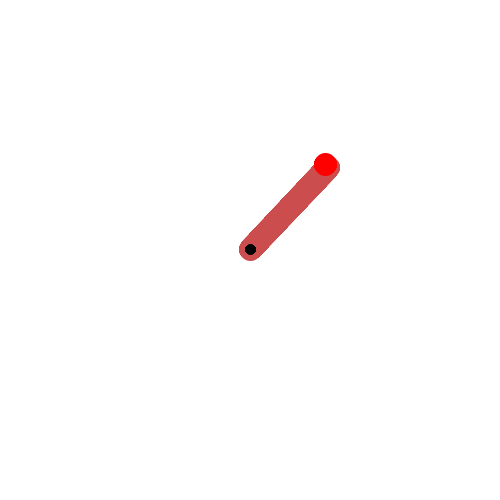
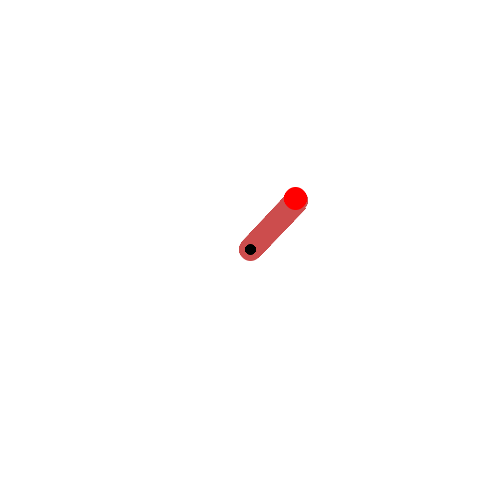

In [6]:
model = SAC.load("models/sac_linear_pendulum")
seed = 0
ideal_linear_history, ideal_image = evaluate(
    model,
    linear_env,
    seed=seed,
    options={
        "m": 1.0,
        "l": 1.0,
        "g": 10.0,
        "b": 1.0
 }
)
real_linear_history, real_image = evaluate(
    model, 
    linear_env,
    seed=seed,
    options={
        "m": 1.4,
        "l": 0.6,
        "g": 9.8,
        "b": 0.4
 }
)


# Build the layout
html_content = f"""
<div style="display: flex; flex-direction: row; justify-content: space-around; width: 100%;">
    {get_gif_html(ideal_image.getvalue(), "Ideal Simulation")}
    {get_gif_html(real_image.getvalue(), "Real-World Simulation")}
</div>
"""

display(HTML(html_content))

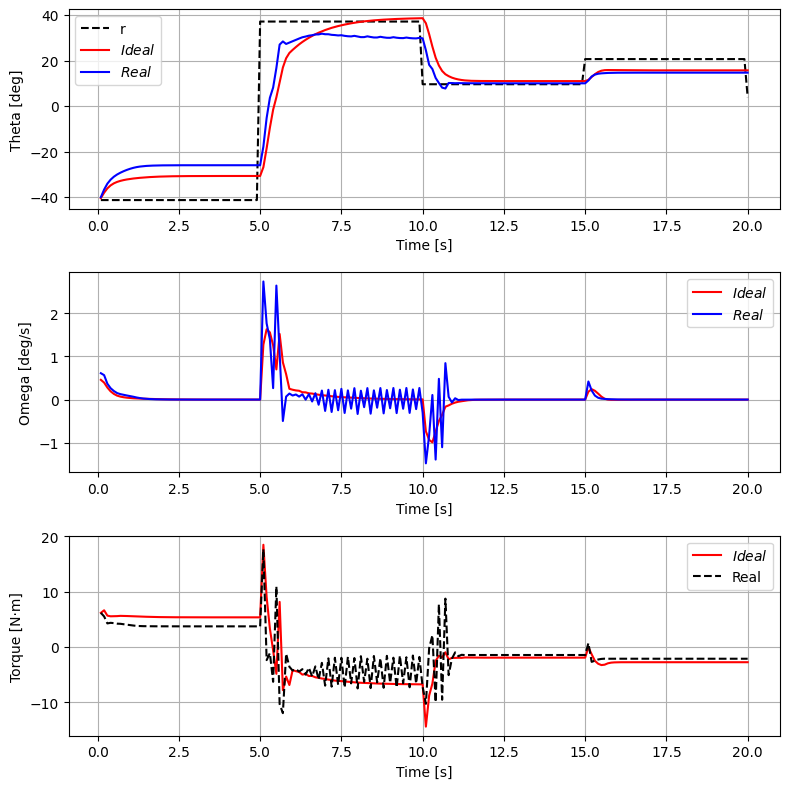

In [7]:
plot_history(real_linear_history, ideal_linear_history)

##### Integrating MRAC to the RL linear model

Recalling the equations:

###### **System dynamics**
$$
\ddot{\theta} = \frac{g}{\ell}\theta - \frac{b}{m \ell^2}\dot{\theta} + \frac{1}{m \ell^2} u
$$

###### **Reference Model**
Parameters $\ell = 1$, $m = 1$, $g = 10$, $b=1$.\
State $x =  \begin{bmatrix} \theta_r, \dot{\theta}_r \end{bmatrix}$\
$$
A_r = \begin{bmatrix}
0 & 1\\
\frac{g_r}{\ell_r} & -\frac{b_r}{m_r\ell^2_r}
\end{bmatrix}, \quad
B_r = \begin{bmatrix}
0\\
\frac{1}{m_r\ell^2_r}
\end{bmatrix}
$$

In [8]:
m_r, l_r, g_r, b_r_phys = 1.0, 1.0, 10.0, 1.0
 
# Scalar entries of the companion-form matrices
a1_r = g_r / l_r                    # > 0 → ω > 1  in D
a2_r = -b_r_phys / (m_r * l_r**2)  # < 0 → ψ ≤ 0  in D
br   = 1.0 / (m_r * l_r**2)        # non-zero element of B_r
 
Ar = np.array([[0.0,  1.0 ],
               [a1_r, a2_r]])      # (2,2) reference system matrix
 
Br = np.array([0.0,
               br])            # (2,) reference input matrix

###### **D Matrix**
In the papers they defined $\omega_1 = 2$ and $\psi_2 = 0$. $\psi_1 = 0$ is chosen to zero because we are controlling only $\theta$, not $\dot{\theta}$
$$
D_{ii} = \begin{cases}
\omega_i > 1 & \text{if } a_{i,r} > 0  \\ 
\psi_i \leq 0 & \text{if } a_{i,r} < 0
\end{cases}
$$

$$
D = \text{diag}(\omega_1,\ \psi_2)
$$

$$
D\alpha_r = \begin{bmatrix}
\omega_1 \cdot \frac{g_r}{\ell_r} \\
\psi_2 \cdot  -\frac{b_r}{m_r\ell^2_r}
\end{bmatrix}
$$

PD: $\alpha_r$ is the last row of $A_r$

###### **A Hurwitz**

$$
\begin{aligned}
A_H &= A_r - h(D\alpha_r)^\top \\
&= \begin{bmatrix}0&1\\\frac{g_r}{\ell_r}&-\frac{b_r}{m_r\ell^2_r}\end{bmatrix} - \begin{bmatrix}0\\1\end{bmatrix}\begin{bmatrix}\omega_1 \cdot \frac{g_r}{\ell_r}&\psi_2 \cdot  -\frac{b_r}{m_r\ell^2_r}\end{bmatrix} \\
\end{aligned}
$$

In [9]:
omega_1 = 2.0   # > 1  (applied to a1_r > 0)
psi_2   = 0.0   # ≤ 0  (applied to a2_r < 0)
 
D = np.diag([omega_1, psi_2])          # (2,2) diagonal

alpha_r = np.array([a1_r, a2_r])   # last row of A_r  (shape 2,)
h       = np.array([[0.0], [1.0]]) # selection vector  (shape 2,1)
 
D_alpha_r = D @ alpha_r                # (2,)  = [2·a1_r,  0·a2_r]
                                        #      = [20.0,    0.0   ]

AH = Ar - h @ D_alpha_r.reshape(1, 2)  # (2,2)

eigs_AH = np.linalg.eigvals(AH)
print(f"  A_H =\n{AH}")
print(f"  A_H eigenvalues: {eigs_AH}  (Re < 0 → Hurwitz ✓)")

  A_H =
[[  0.   1.]
 [-10.  -1.]]
  A_H eigenvalues: [-0.5+3.122499j -0.5-3.122499j]  (Re < 0 → Hurwitz ✓)


###### **Lyapunov equation**
Solve for $P$:
$$
P A_H + A_H^\top P = - Q
$$

In [10]:
from scipy.linalg import solve_continuous_lyapunov

Q = np.eye(2)  # design choice: Q = I
P = solve_continuous_lyapunov(AH.T, -Q)
 
eigs_P = np.linalg.eigvals(P)
print(f"  P =\n{P}")
print(f"  P eigenvalues: {eigs_P}  (> 0 → P ≻ 0 ✓)")

  P =
[[5.55 0.05]
 [0.05 0.55]]
  P eigenvalues: [5.55049995 0.54950005]  (> 0 → P ≻ 0 ✓)


###### **Augmented reference input $\xi$**
$$
\begin{aligned}
\xi(t) &= u_r - \frac{1}{b_r}(D\alpha_r)^\top e \\
&= u_r - \frac{2\cdot a_{1,r}}{b_r}\, e_\theta \\
&= u_r - 2g_r m_r \ell_r  e_\theta
\end{aligned}
$$
PD: $\psi_2=0$ kills the $\dot{\theta}$ error term

In [11]:
def compute_xi(ur: float, e: np.ndarray) -> float:
    """
    Augmented reference input.
      ur  : scalar reference control from RL policy
      e   : tracking error  [e_θ, e_ω]  (shape 2,)
    Returns scalar ξ.
    """
    return ur - (D_alpha_r @ e) / br   # = ur − (1/br)(Dαr)ᵀ e

###### **MRAC Control law**

$$
u(t) = \hat{K}_x^\top(t)\, x(t) + \hat{k}_u(t)\, \xi(t)
$$

In [12]:
def compute_u(K_x_hat: np.ndarray, k_u_hat: float,
              X: np.ndarray, xi: float) -> float:
    """
    Adaptive control law.
      K_x_hat : (2,)   adaptive state feedback gain
      k_u_hat : scalar adaptive feedforward gain
      X       : (2,)   true plant state [θ, θ̇]
      xi      : scalar augmented reference input
    Returns scalar torque u.
    """
    return float(K_x_hat @ X) + k_u_hat * xi

###### **Update Adaptive Gains**

$$\dot{\hat{K}}_x(t) = -\Gamma_x\, x(t)\, e^\top(t) P B_r$$

$$\dot{\hat{k}}_u(t) = -\gamma_u\, \xi(t)\, e^\top(t) P B_r$$


In [13]:
def update_params(K_x_hat: np.ndarray, k_u_hat: float,
                  X: np.ndarray, e: np.ndarray, xi: float,
                  Gamma_x: np.ndarray, gamma_u: float,
                  dt: float):
    """
    One Euler step of the adaptive parameter update laws.
 
    Parameters
    ----------
    K_x_hat : (2,)   current K̂_x
    k_u_hat : float  current k̂_u
    X       : (2,)   true state
    e       : (2,)   tracking error  x − x_r
    xi      : float  augmented reference input ξ
    Gamma_x : (2,2)  adaptation gain matrix Γ_x
    gamma_u : float  adaptation gain scalar γ_u
    dt      : float  integration time step Δt
 
    Returns
    -------
    K_x_hat_new, k_u_hat_new
    """
    # ePBr = eᵀ P B_r  — a scalar that drives both update laws
    # Dimension trace: (1×2)(2×2)(2×1) → scalar
    ePBr = float(e @ P @ Br)
 
    # K̂_x update: shape (2,) −= scalar * (2,2)(2,) * scalar
    K_x_hat_new = K_x_hat - dt * (Gamma_x @ X) * ePBr
 
    # k̂_u update: scalar −= scalar * scalar * scalar
    k_u_hat_new = k_u_hat - dt * gamma_u * xi * ePBr
 
    return K_x_hat_new, k_u_hat_new
 

In [14]:
def run_episode(model, ideal_env, real_env,
                ideal_options, real_options,
                Gamma_x, gamma_u,
                use_mrac: bool = True,
                seed: int = 42):
    """
    Run one episode.
 
    use_mrac = True  → MRAC-RL: adaptive inner loop modifies u
    use_mrac = False → Baseline: policy applied directly to true plant
                       (standard RL, no adaptive correction)
    """
    obs_r, _ = ideal_env.reset(seed=seed, options=ideal_options)
    obs,   _ = real_env.reset( seed=seed, options=real_options)
 
    # Sync initial states so differences come only from dynamics, not ICs
    real_env.unwrapped.state = ideal_env.unwrapped.state.copy()
    obs = real_env.unwrapped._get_obs()
 
    dt = ideal_env.unwrapped.dt
 
    # K̂_x(0) = 0: if λ=1 and A=Ar, ideal K_x* = 0 (policy handles everything)
    # k̂_u(0) = 1: ideal k_u* = 1/λ; start at 1 (correct if λ=1)
    K_x_hat = np.zeros(2)
    k_u_hat = 1.0
 
    history = {k: [] for k in ["t", "r", "theta", "theta_r", "e_theta",
                            "u", "ur", "K_x_hat", "k_u_hat", "xi"]}
    t = 0.0
    terminated = truncated = False
 
    while not (terminated or truncated):
 
        # OUTER LOOP: policy acts on reference model state
        ur_action, _ = model.predict(obs_r, deterministic=True)
        ur = float(ur_action[0])
 
        # Read raw states (not observations) 
        X_r = ideal_env.unwrapped.state.copy()
        X   = real_env.unwrapped.state.copy()
 
        # Tracking error 
        e       = X - X_r
        e_theta = e[0]
 
        if use_mrac:
            # Augmented reference input ξ 
            xi = compute_xi(ur, e)
 
            # MRAC control law  u = K̂_xᵀ x + k̂_u ξ 
            u = compute_u(K_x_hat, k_u_hat, X, xi)
 
            # Parameter update laws (Euler step) 
            K_x_hat, k_u_hat = update_params(
                K_x_hat, k_u_hat, X, e, xi, Gamma_x, gamma_u, dt
            )
        else:
            # Baseline: Compute action over real plant
            u_action, _ = model.predict(obs, deterministic=True)
            u = float(u_action[0])
            xi = ur 
        
        # Step environments 
        # Reference model advances under policy output ur
        obs_r, _, term_r,  trunc_r,  _ = ideal_env.step([ur])
        # True plant advances under MRAC output u
        obs,   _, terminated, truncated, _ = real_env.step([u])
 
        terminated = terminated or term_r
        truncated  = truncated  or trunc_r
 
        # history 
        history["t"].append(t)
        history["theta"].append(X[0])
        history["theta_r"].append(X_r[0])
        history["e_theta"].append(e_theta)
        history["u"].append(u)
        history["ur"].append(ur)
        history["K_x_hat"].append(K_x_hat.copy())
        history["k_u_hat"].append(k_u_hat)
        history["xi"].append(xi)
        
        r = ideal_env.unwrapped.target_angle
        history['r'].append(r)
 
        t += dt
 
    return history

In [15]:
model     = SAC.load("models/sac_linear_pendulum")
ideal_env = gym.make("LinearSRIPPendulum-v0")
real_env  = gym.make("LinearSRIPPendulum-v0")

ideal_options = {"m": m_r, "l": l_r, "g":  g_r, "b": b_r_phys}
real_options  = {"m": 1.2, "l": 0.7, "g":  9.8, "b": 0.7}
 
# True λ (unknown to controller, computed only for reference/display)
lambda_true = (m_r * l_r**2) / (real_options["m"] * real_options["l"]**2)
print(f"\n  True λ = (m_r·l_r²)/(m·l²) = {lambda_true:.4f}  (unknown to MRAC)")
 
Gamma_x = np.diag([1, 5])   # state feedback adaptation gain  Γ_x
gamma_u = 1.0                # feedforward adaptation gain  γ_u
 
seed = 2
history_mrac = run_episode(model, ideal_env, real_env,
            ideal_options, real_options,
            Gamma_x, gamma_u,
            use_mrac=True, seed=seed)

history_baseline = run_episode(model, ideal_env, real_env,
            ideal_options, real_options,
            Gamma_x, gamma_u,
            use_mrac=False, seed=seed)


  True λ = (m_r·l_r²)/(m·l²) = 1.7007  (unknown to MRAC)


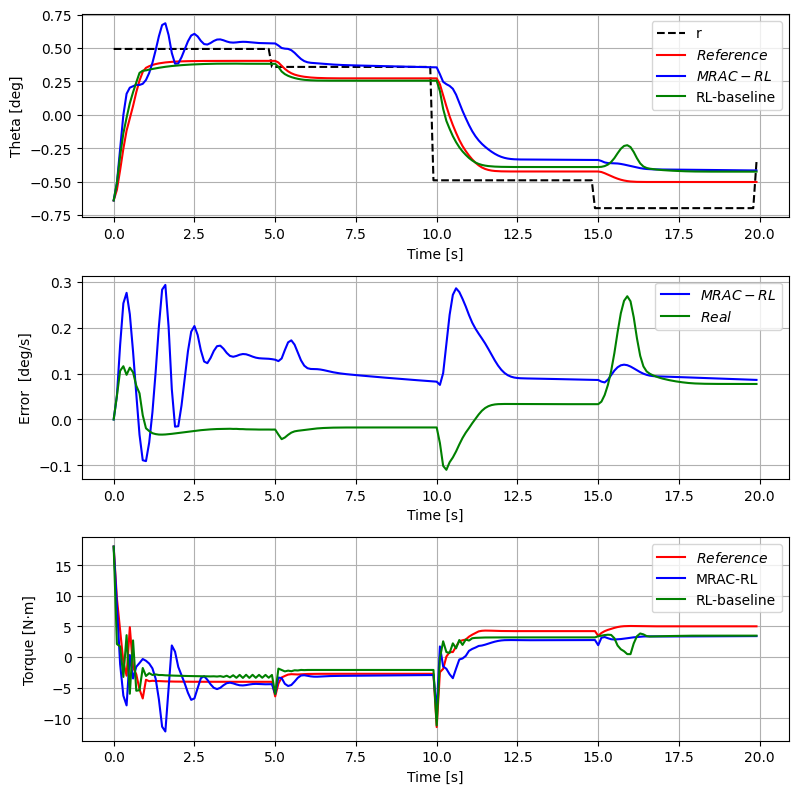

In [16]:
fig = plt.figure(figsize=(8, 8))
time = history_mrac['t']
plt.subplot(3,1,1)
plt.plot(time, history_mrac['r'], 'k--', label=r'r')    
plt.plot(time, history_mrac['theta_r'], 'r', label=r'$Reference$')
plt.plot(time, history_mrac['theta'], 'b', label=r'$MRAC-RL$')
plt.plot(time, history_baseline['theta'], 'g', label=r'RL-baseline')
plt.xlabel('Time [s]')
plt.ylabel('Theta [deg]')
plt.grid()
plt.legend()

plt.subplot(3,1,2)
plt.plot(time, history_mrac['e_theta'], 'b', label=r'$MRAC-RL$')
plt.plot(time, history_baseline['e_theta'], 'g', label=r'$Real$')
plt.xlabel('Time [s]')
plt.ylabel('Error  [deg/s]')
plt.grid()
plt.legend()

plt.subplot(3,1,3)
plt.plot(time, history_mrac['ur'], 'r', label=r'$Reference$')
plt.plot(time, history_mrac['u'], 'b', label=r'MRAC-RL')
plt.plot(time, history_baseline['u'], 'g', label=r'RL-baseline')
plt.xlabel('Time [s]')
plt.ylabel('Torque [N·m]')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

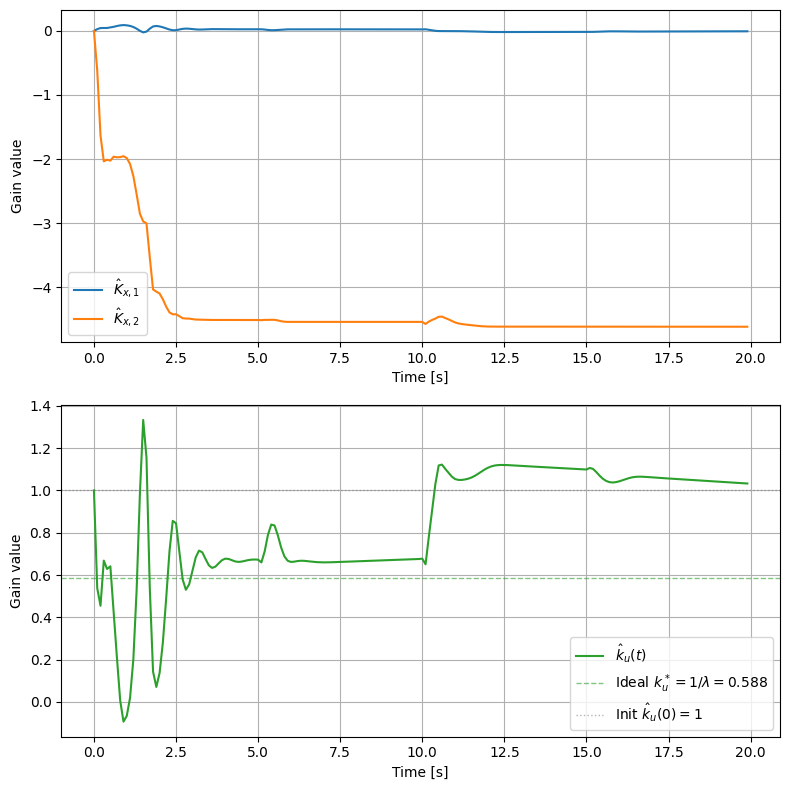

In [17]:
fig = plt.figure(figsize=(8, 8))
time = history_mrac['t']
plt.subplot(2,1,1)
K_x_hat_arr = np.array(history_mrac["K_x_hat"])
plt.plot(time, K_x_hat_arr[:, 0], "C0-", lw=1.5,
         label=r"$\hat{K}_{x,1}$")
plt.plot(time, K_x_hat_arr[:, 1], "C1-", lw=1.5,
         label=r"$\hat{K}_{x,2}$ ")
plt.xlabel('Time [s]')
plt.ylabel('Gain value')
plt.grid()
plt.legend()

plt.subplot(2,1,2)
plt.plot(time, history_mrac["k_u_hat"], "C2-", lw=1.5,
         label=r"$\hat{k}_u(t)$")
k_u_star = 1.0 / lambda_true
plt.axhline(k_u_star, color="C2", ls="--", lw=1.0, alpha=0.6,
            label=rf"Ideal $k^*_u = 1/\lambda = {k_u_star:.3f}$")
plt.axhline(1.0, color="gray", ls=":", lw=1.0, alpha=0.6,
            label=r"Init $\hat{k}_u(0) = 1$")
#plt.plot(time, history_baseline['e_theta'], 'g', label=r'$Real$')
plt.xlabel('Time [s]')
plt.ylabel('Gain value')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

## Nonlinear Example
Parameters taken from the appendix of the paper
* $T=200$: Horizon - Number of steps
* $\gamma=0.99$: Discount factor
* $\alpha=5e-4$: Learning rate for both actor and critic networks
* Total time (training) steps: $9e5$

In [18]:
gym.register(
    id="NonlinearSRIPPendulum-v0",
    entry_point="srip_pendulum_env:NonlinearSRIPPendulumEnv",
    kwargs={"render_mode": "rgb_array"},
    max_episode_steps=200,
)
nonlinear_env = gym.make("NonlinearSRIPPendulum-v0")

In [19]:
%%time
nonlinear_env.reset(seed=42)
model = SAC("MlpPolicy", nonlinear_env, 
            gamma=0.99, learning_rate=5e-4,
            verbose=1)
model.learn(total_timesteps=9e5, log_interval=500)
model.save("models/sac_nonlinear_pendulum")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -82.8    |
| time/              |          |
|    episodes        | 500      |
|    fps             | 73       |
|    time_elapsed    | 1363     |
|    total_timesteps | 100000   |
| train/             |          |
|    actor_loss      | 52.4     |
|    critic_loss     | 2.17     |
|    ent_coef        | 0.0708   |
|    ent_coef_loss   | 0.0876   |
|    learning_rate   | 0.0005   |
|    n_updates       | 99899    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -79.3    |
| time/              |          |
|    episodes        | 1000     |
|    fps             | 71       |
|    time_elapsed    | 2777     |
|    total_timesteps | 200000   |
| train/             |


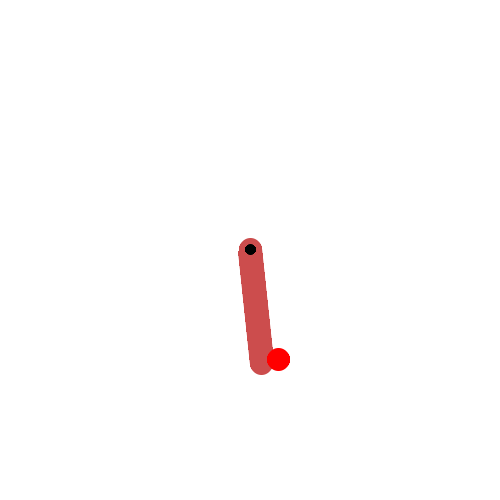
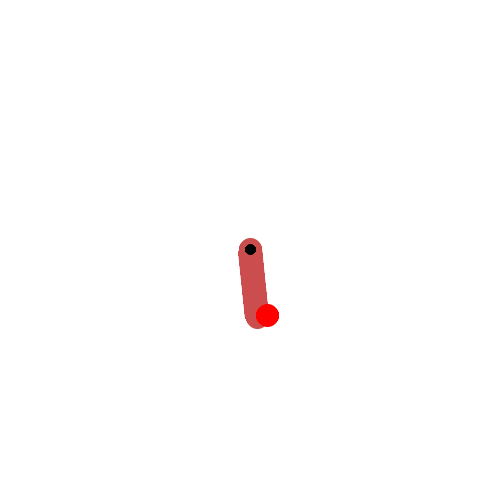

In [22]:
model = SAC.load("models/sac_nonlinear_pendulum")
seed = 0
ideal_nonlinear_history, ideal_image = evaluate(
    model,
    nonlinear_env,
    seed=seed,
    options={
        "m": 1.0,
        "l": 1.0,
        "g": 10.0,
        "b": 1.0
 }
)
real_nonlinear_history, real_image = evaluate(
    model, 
    nonlinear_env,
    seed=seed,
    options={
        "m": 1.4,
        "l": 0.6,
        "g": 9.8,
        "b": 0.4
 }
)


# Build the layout
html_content = f"""
<div style="display: flex; flex-direction: row; justify-content: space-around; width: 100%;">
    {get_gif_html(ideal_image.getvalue(), "Ideal Simulation")}
    {get_gif_html(real_image.getvalue(), "Real-World Simulation")}
</div>
"""

display(HTML(html_content))

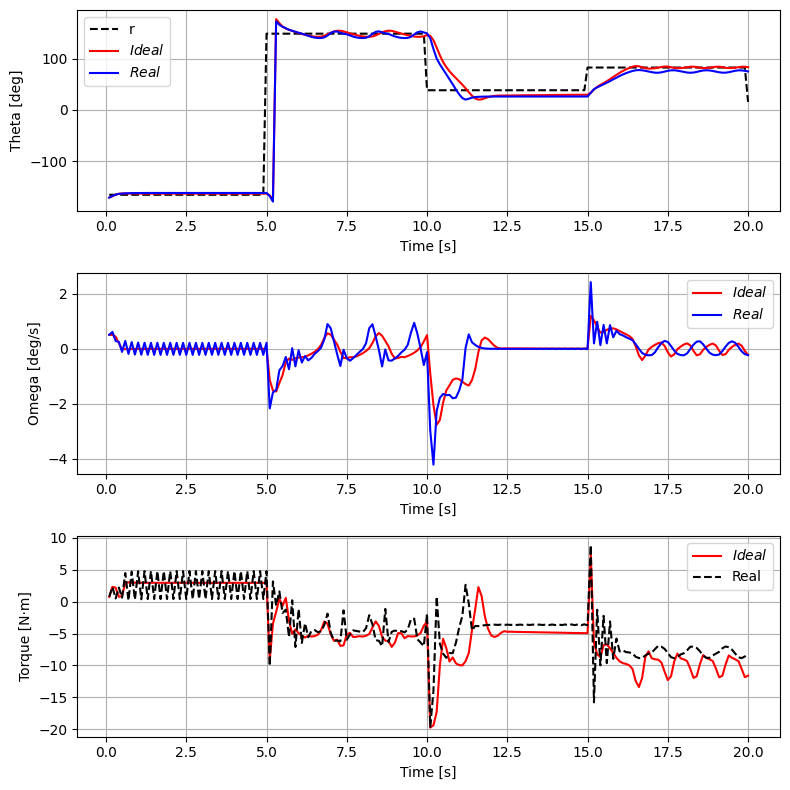

In [23]:
plot_history(real_nonlinear_history, ideal_nonlinear_history)